# Классификация текстов с использованием Наивного Байесовского Классификатора

## Задание 1 (1 балл)

Откройте данные. Узнайте, сколько в них спам- и не спам-писем. Визуализируйте полученные соотношение подходящим образом.

In [39]:
# откройте данные: ваш код здесь

#Загружаем необходимую библиотеку
import pandas as pd

#Загружаем данные 
data = pd.read_csv('data/spam_or_not_spam.csv')

#Выводим таблицу data
display(data)

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0
...,...,...
2995,abc s good morning america ranks it the NUMBE...,1
2996,hyperlink hyperlink hyperlink let mortgage le...,1
2997,thank you for shopping with us gifts for all ...,1
2998,the famous ebay marketing e course learn to s...,1


In [40]:
# рассчитайте частоты для классов : ваш код здесь

#Рассчитываем частоты для классов
value_cnt_label = data['label'].value_counts()

#Выводим value_cnt_label
print(value_cnt_label)

#Выводим информативный вариант
print(f"\nКоличество не спам-писем: {value_cnt_label[0]}")
print(f"Количество спам-писем: {value_cnt_label[1]}")

label
0    2500
1     500
Name: count, dtype: int64

Количество не спам-писем: 2500
Количество спам-писем: 500


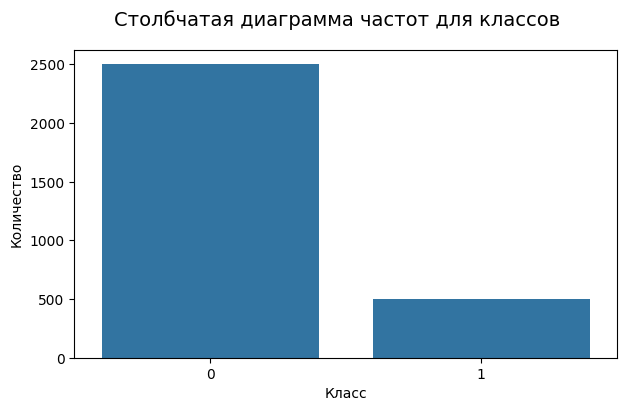

In [41]:
# визуализируйте результат: ваш код здесь

#Загружаем необходимые библиотеки
import matplotlib.pyplot as plt
import seaborn as sns

#Создаем координатную плоскость
fig, ax = plt.subplots(figsize=(7,4))

#Создаем столбчатую диаграмму
sns.barplot(x=value_cnt_label.index, y=value_cnt_label.values)

#Даем название осям
ax.set_xlabel('Класс')
ax.set_ylabel('Количество')

#Даем название графику
fig.suptitle('Столбчатая диаграмма частот для классов', fontsize=14);

## Задание 2 (2 балла)

Вам необходимо предобработать ваши данные и перевести их в векторный вид. Подгрузим необходимый модуль:

In [42]:
from sklearn.feature_extraction.text import CountVectorizer

Замените в данных все пустые строки и строки, состоящие из пробелов, на пропуски (NaN). После этого удалите из данных все строки, в которых наблюдаются пропущенные значения.

In [ ]:
#ваш код здесь

#Загрузка необходимых библиотек
import numpy as np

#Замена всех пустых и пробельных значений на NaN
data = data.replace(r'^\s*$', np.nan, regex=True)

#Удаление данных с пропусками
data = data.dropna()


Переводим данные в векторный вид:

In [74]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data["email"])

Определите, сколько теперь признаков в нашем наборе данных:

In [75]:
#ваш код здесь

#Количество признаков после предобработки данных
print(f"Количество признаков после обработки: {X.shape[1]}")

Количество признаков после обработки: 34116


## Задание 3 (2 балла)

Определите целевую переменную и признаки:

In [ ]:
#ваш код здесь

#X определен ранее
y = data['label']

Разделите выборку на обучающую и тестовую, используя стратифицированное разбиение (параметр `stratify` установите в значение вектора ответов y) размер тестовой выборки (`test_size`) возьмите как 0.25, параметр `random_state` определите со значением 42:

In [ ]:
#ваш код здесь

#Разбиение выборки на train и test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

Рассчитайте среднее значение целевой переменной по тестовой выборке:

In [78]:
#ваш код здесь

#Рассчет среднего значения целевой пременной для тестовой выборки
print(f"Среднее значение целевой пременной для тестовой выборки: "
      f"{round(y_test.mean(),3)}")

Среднее значение целевой пременной для тестовой выборки: 0.165


## Задание 4 (3 балла)

Определите и обучите подходящий алгоритм с параметром alpha = 0.01

In [79]:
#ваш код здесь

#Загрузка необходимых библиотек
from sklearn.naive_bayes import ComplementNB
#Создание и обучение модели
model = ComplementNB(alpha=0.01)
model.fit(X_train, y_train)

#Предсказание модели модели 
y_pred = model.predict(X_test)

Оцените результат с точки зрения всех известных вам метрик (не менее трёх):

In [82]:
#ваш код здесь

#Загрузка необходимых библиотек
from sklearn.metrics import accuracy_score, precision_score, f1_score

#Метрики качества
print(f'Accuracy: {round(accuracy_score(y_test, y_pred), 3)}')
print(f'Precision: {round(precision_score(y_test, y_pred), 3)}')
print(f'F1-score: {round(f1_score(y_test, y_pred), 3)}')

Accuracy: 0.988
Precision: 1.0
F1-score: 0.962


Нарисуйте ROC-кривую:

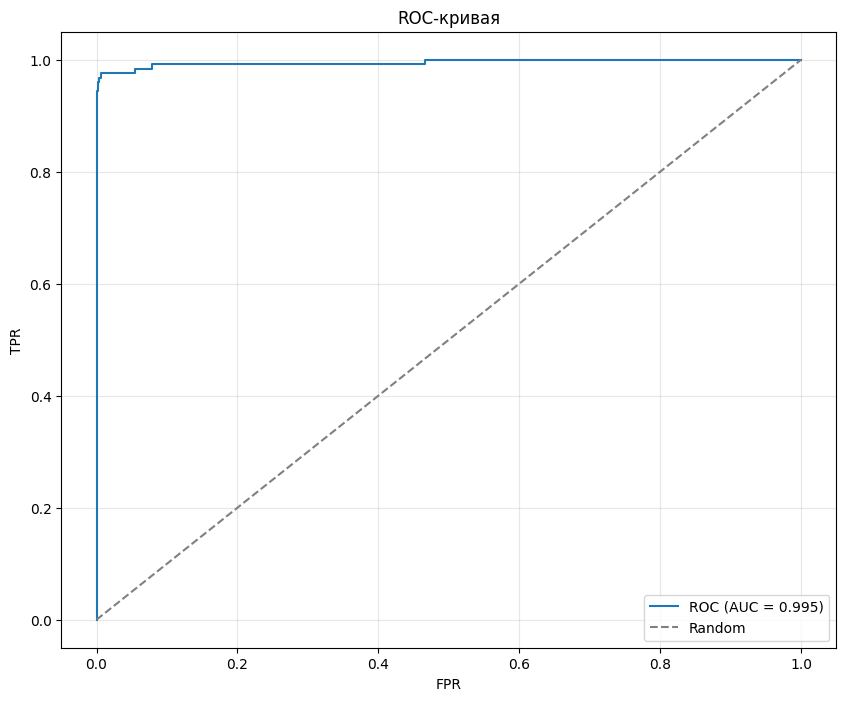

In [85]:
#ваш код здесь

#Загрузка необходимых библиотке
from sklearn.metrics import roc_curve, roc_auc_score

#Получение вероятностных предсказаний
y_proba = model.predict_proba(X_test)[:, 1]

#Расчет точек ROC-кривой
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

#AUC
auc = roc_auc_score(y_test, y_proba)

#ROC-AUC кривая
fig, ax = plt.subplots(figsize = (10, 8))
ax.plot(fpr, tpr, label=f'ROC (AUC = {auc:.3f})')
ax.plot([0,1], [0, 1], linestyle = '--', color= 'gray', label='Random')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('ROC-кривая')
ax.legend()
ax.grid(alpha=0.3)


## Задание 5 (3 балла)

Переберите несколько значений alpha с помощью кросс-валидации. Оцените, зависит ли от этого параметра качество классификации.

,alpha,mean,std
0,0.001,0.987096,0.004945
1,0.010,0.989319,0.002947
2,0.100,0.990209,0.003876
3,0.200,0.991099,0.003144
4,0.500,0.990655,0.002591
5,1.000,0.990210,0.003324
6,2.000,0.984869,0.006197


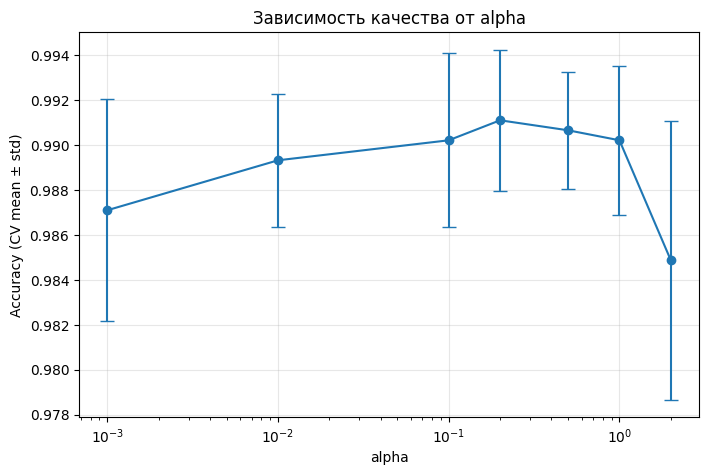

In [90]:
#ваш код здесь

#Загрузка необходимых библиотек
from sklearn.model_selection import cross_val_score

#Список alphas
alphas = [0.001, 0.01, 0.1, 0.2, 0.5, 1.0, 2.0]

#Заготовка пустого списка для результатов
results = []

#Реализация подбора alpha через cv при помощи цикла
for alpha in alphas:
    model = ComplementNB(alpha=alpha)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring='accuracy',
        n_jobs=-1
    )
    results.append({
        'alpha': alpha,
        'mean': scores.mean(),
        'std': scores.std()
    })
    
#Преобразование результатов в df формат    
results_df = pd.DataFrame(results)

#Вывод итоговой таблицы
display(results_df)

#График результатов
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    results_df['alpha'], results_df['mean'],
    yerr=results_df['std'],
    marker='o', capsize=5
)
ax.set_xscale('log')   # alpha меняется на порядки — лог-шкала удобнее
ax.set_xlabel('alpha')
ax.set_ylabel('Accuracy (CV mean ± std)')
ax.set_title('Зависимость качества от alpha')
ax.grid(alpha=0.3)



# Вывод задание 5
Качество классификации зависит от параметра alpha. 

Лучший результат был достигнут при значении alpha = 0.2 и составил 0.991.